## Введение

# Проект. Исследование стартапов
Исполнитель Жданова Мария

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод». <br>


Проект для финансовой компании, которая работает с венчурными инвестициями Цель проекта - провести исследование на исторических данных, чтобы понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
#загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.colors as mcolors

<span style="color: green">Добавила библиотеку с цветами для графиков: import matplotlib.colors as mcolors</span> 

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
#загружаем данные
df_cb_investments = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_cb_returns = pd.read_csv('https://code.s3.yandex.net/datasets/cb_returns.csv')


Выведите информацию, которая необходима для принятия решений о предобработке.

In [3]:
#смотрим датасет df_cb_investments 
df_cb_investments.info()
df_cb_investments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
#смотрим датасет df_cb_returns
df_cb_returns.info()
df_cb_returns.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет df_cb_investments:<br>
funding_total_usd тип object, хотя хранит числовые данные,<br>
founded_at, founded_month, founded_quarter, first_funding_at, mid_funding_at, last_funding_at тип object, хотя хранит дату<br> 
founded_year тип float64, хотя хранит дату.<br>
Пропущенные значения есть во всех столбцах.<br>
Объем датасета 16.6 МБ.<br>
Данные соответствуют описанию.




Датасет df_cb_returns:<br>
year тип данных int64, хотя хранит дату. <br> 
Пропусков нет.<br> 
Объем датасета 1.8 Кб.<br> 
Данные соответствуют описанию.

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [5]:
#корректируем названия столбцов
df_cb_investments.columns = df_cb_investments.columns.str.strip()
df_cb_investments = df_cb_investments.rename(columns={
    'round_A': 'round_a',
    'round_B': 'round_b',
    'round_C': 'round_c',
    'round_D': 'round_d',
    'round_E': 'round_e',
    'round_F': 'round_f',
    'round_G': 'round_g',
    'round_H': 'round_h',
    ' market': 'market',
    ' funding_total_usd': 'funding_total_usd'
})


Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [6]:
#приводим столбец funding_total_usd к числовому типу
df_cb_investments['funding_total_usd'] = (
    df_cb_investments['funding_total_usd']
    .astype(str) 
    .str.replace(',', '', regex=False)  
    .pipe(pd.to_numeric, errors='coerce')  
)
print(df_cb_investments['funding_total_usd'].head(5))

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64


Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [7]:
#меняем тип данных в founded_at на datetime
df_cb_investments['founded_at'] = pd.to_datetime(
    df_cb_investments['founded_at'],
    errors='coerce'
)


In [8]:
#меняем тип данных в founded_month на datetime
df_cb_investments['founded_month'] = pd.to_datetime(
    df_cb_investments['founded_month'],
    format='%Y-%m',
    errors='coerce'
)


In [9]:
#меняем тип данных в founded_quarter на datetime
df_cb_investments['founded_quarter'] = pd.PeriodIndex(
    df_cb_investments['founded_quarter'],
    freq='Q'
)


In [10]:
#меняем тип данных в first_funding_at на datetime
df_cb_investments['first_funding_at'] = pd.to_datetime(
    df_cb_investments['first_funding_at'],
    errors='coerce'
)

In [11]:
#меняем тип данных в mid_funding_at на datetime
df_cb_investments['mid_funding_at'] = pd.to_datetime(
    df_cb_investments['mid_funding_at'],
    errors='coerce'
)

In [12]:
#меняем тип данных в last_funding_at на datetime
df_cb_investments['last_funding_at'] = pd.to_datetime(
    df_cb_investments['last_funding_at'],
    errors='coerce'
)

In [13]:
#меняем тип данных в founded_year на datetime
df_cb_investments['founded_year'] = pd.to_datetime(
    df_cb_investments['founded_year'],
    format='%Y',
    errors='coerce',
)

In [14]:
#проверяем что получилось после преобразования типов данных
df_cb_investments[['founded_at', 'founded_month', 'founded_quarter',
                  'first_funding_at', 'mid_funding_at', 'last_funding_at', 'founded_year']].head()

,founded_at,founded_month,founded_quarter,first_funding_at,mid_funding_at,last_funding_at,founded_year
0,NaT,NaT,NaT,2014-01-06,NaT,2014-01-06,NaT
1,1785-01-01,NaT,NaT,2014-05-15,NaT,2014-05-15,1785-01-01
2,1802-07-19,NaT,NaT,2009-07-02,2009-07-02,2009-07-02,1802-01-01
3,1817-01-01,NaT,NaT,2013-11-21,2013-11-21,2014-11-03,1817-01-01
4,1826-01-01,NaT,NaT,2014-01-14,NaT,2014-01-14,1826-01-01


In [15]:
df_cb_investments[['founded_at', 'founded_month', 'founded_quarter',
                  'first_funding_at', 'mid_funding_at', 'last_funding_at', 'founded_year']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   founded_month     38482 non-null  datetime64[ns]
 2   founded_quarter   38482 non-null  period[Q-DEC] 
 3   first_funding_at  49428 non-null  datetime64[ns]
 4   mid_funding_at    30288 non-null  datetime64[ns]
 5   last_funding_at   49432 non-null  datetime64[ns]
 6   founded_year      38553 non-null  datetime64[ns]
dtypes: datetime64[ns](6), period[Q-DEC](1)
memory usage: 2.9 MB


В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [16]:
#делаем столбцец year индексом
df_cb_returns = df_cb_returns.set_index('year')
df_cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [17]:
#заменяем пропуски на заглушки
columns_to_fill = [
    'name',
    'homepage_url',
    'category_list',
    'market',
    'status',
    'country_code',
    'state_code',
    'region',
    'city'
]

df_cb_investments[columns_to_fill] = df_cb_investments[columns_to_fill].fillna('нет данных')

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [18]:
#удаляем строки, где funding_total_usd нет данных
df_clean = df_cb_investments.dropna(subset=['funding_total_usd'])


In [19]:
#удаляем полные дубликаты
df_clean = df_clean.drop_duplicates(
    subset=['name', 'funding_total_usd', 'homepage_url'],
    keep='first'
)

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [20]:
#заполняем пропуски в mid_funding_at
mask = df_clean['mid_funding_at'].isna()
df_clean.loc[mask, 'mid_funding_at'] = (
    df_clean.loc[mask, 'first_funding_at'] +
    (df_clean.loc[mask, 'last_funding_at'] -
     df_clean.loc[mask, 'first_funding_at']) / 2)

In [21]:
#убираем лишние пробелы в market  и приводим к единому формату
df_clean['market'] = (
    df_clean['market']
    .str.strip()           
    .str.replace(r'\s+', ' ', regex=True)  
    .str.title()          
)


Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [22]:
# считаем абсолютное и относительное кол-во пропусков
print('абсолютное кол-во пропусков:')
print(df_clean.isna().sum()) 
print()
print('относительное кол-во пропусков:')
print(df_clean.isna().sum() / df_clean.shape[0]) 

абсолютное кол-во пропусков:
name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            13574
founded_at               8705
founded_month            8770
founded_quarter          8770
founded_year             8705
first_funding_at            2
mid_funding_at              1
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a    

In [23]:
#считаем сколько данных удалено из датасета, абсолютное и относительное кол-во 
how_much_drop = df_cb_investments.shape[0] - df_clean.shape[0]
print('абсолютное кол-во удаленных данных:')
print(how_much_drop)
print()
print('процент удаленных данных:')
how_much_drop_ratio = round((how_much_drop / df_cb_investments.shape[0]) *100, 2)
print(how_much_drop_ratio)

абсолютное кол-во удаленных данных:
13393

процент удаленных данных:
24.67


Промежуточный вывод:
1. Выгружены библиотеки и датасеты.
2. Скорректированы названия столбцов и типы данных.
3. Пропуски в текстовых столбцах заменены на заглушки, в mid_funding_at на среднее значение.
4. Удалены дубликаты, результат сохранен в новый датасет df_clean.
5. Посчитано абсолютное и относительное кол-во пропусков.
6. Удалено из исходного датасета 13393, что составило 24.67%.



## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [24]:
#делим компании на три группы
#предварительно скорректируем тип данных у funding_rounds
df_clean['funding_rounds'] = df_clean['funding_rounds'].astype(int)
#берём реальное число раундов и крайние даты
funding_stats = df_clean.groupby('name').agg({
    'funding_rounds': 'sum',           # суммируем раунды по всем строкам компании
    'first_funding_at': 'min',       # первая дата финансирования
    'last_funding_at': 'max'         # последняя дата финансирования
}).reset_index()

#считаем длительность периода финансирования (в днях)
funding_stats['funding_period_days'] = (
    funding_stats['last_funding_at'] - funding_stats['first_funding_at']
).dt.days

#функция категоризации
def assign_category(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['funding_period_days'] <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

funding_stats['category'] = funding_stats.apply(assign_category, axis=1)

#добавляем суммарный объём финансирования по компаниям
total_funding_per_company = df_clean.groupby('name')['funding_total_usd'].sum().reset_index()

funding_stats = funding_stats.merge(
    total_funding_per_company,
    on='name',
    how='left'
)

print(funding_stats['category'].value_counts())
print(funding_stats.head(5))


Единичное финансирование          24062
Срок финансирования более года    12290
Срок финансирования до года        4494
Name: category, dtype: int64
                 name  funding_rounds first_funding_at last_funding_at  \
0            #waywire               1       2012-06-30      2012-06-30   
1  &TV Communications               2       2010-06-04      2010-09-23   
2   'Rock' Your Paper               1       2012-08-09      2012-08-09   
3   (In)Touch Network               1       2011-04-01      2011-04-01   
4  -R- Ranch and Mine               2       2014-08-17      2014-09-26   

   funding_period_days                     category  funding_total_usd  
0                  0.0     Единичное финансирование          1750000.0  
1                111.0  Срок финансирования до года          4000000.0  
2                  0.0     Единичное финансирование            40000.0  
3                  0.0     Единичное финансирование          1500000.0  
4                 40.0  Срок финансирован

In [25]:
#готовим данные для визуализации
#считаем, какой процент от общего числа компаний относится к каждой из трёх групп
name_count = funding_stats['name'].count()


once_cat_ratio = round (((funding_stats[funding_stats['category'] == 'Единичное финансирование'].shape[0])
                         / name_count) * 100,2)
more_than_year_cat_ratio = round (((funding_stats[funding_stats['category'] == 'Срок финансирования более года'].shape[0])
                            / name_count) * 100,2)
less_than_year_cat_ratio = round (((funding_stats[funding_stats['category'] == 'Срок финансирования до года'].shape[0])
                            / name_count) * 100,2)

print(once_cat_ratio)
print(more_than_year_cat_ratio)
print(less_than_year_cat_ratio)



58.91
30.09
11.0


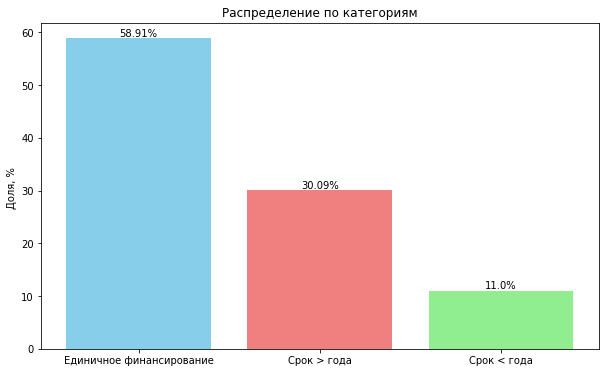

In [26]:
#рисуем график
categories = ['Единичное финансирование', 'Срок > года', 'Срок < года']
ratios = [once_cat_ratio, more_than_year_cat_ratio, less_than_year_cat_ratio]
colors = ['skyblue', 'lightcoral', 'lightgreen']


plt.figure(figsize=(10, 6))
bars = plt.bar(categories, ratios, color=colors)  
 
plt.title('Распределение по категориям')
plt.ylabel('Доля, % ')

# Добавляем подписи значений
for bar, ratio in zip(bars, ratios):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{ratio}%', ha='center', va='bottom')

plt.show()

Вывод: чаще всего встречается единчиное финансирование - 58.91%.

In [27]:
#готовим данные для визуализации
#считаем, какая доля от общего числа инвестиций относится к каждой из трёх групп

#предварительно скорректируем тип данных у funding_total_usd
funding_stats['funding_total_usd'] = funding_stats['funding_total_usd'].astype(int)

usd_count = funding_stats['funding_total_usd'].sum()


once_cat_amount = funding_stats[funding_stats['category'] == 'Единичное финансирование']['funding_total_usd'].sum()
more_than_year_cat_amount = funding_stats[funding_stats['category'] == 'Срок финансирования более года']['funding_total_usd'].sum()
less_than_year_cat_amount = funding_stats[funding_stats['category'] == 'Срок финансирования до года']['funding_total_usd'].sum()

once_cat_ratio_usd = round((once_cat_amount / usd_count) , 4)
more_than_year_cat_ratio_usd = round((more_than_year_cat_amount / usd_count) , 4)
less_than_year_cat_ratio_usd = round((less_than_year_cat_amount / usd_count) , 4)

print(once_cat_ratio_usd)
print(more_than_year_cat_ratio_usd)
print(less_than_year_cat_ratio_usd)


0.3054
0.6195
0.0751


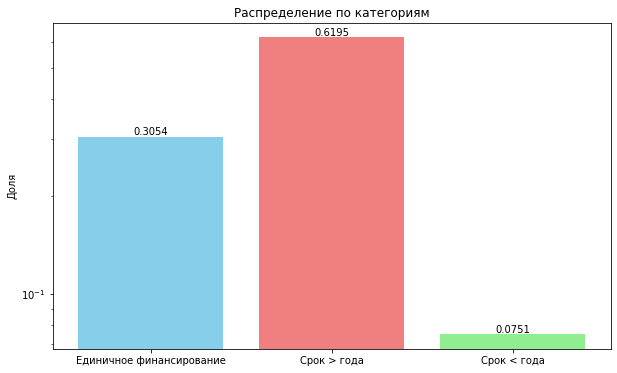

In [28]:
#рисуем график
categories = ['Единичное финансирование', 'Срок > года', 'Срок < года']
ratios = [once_cat_ratio_usd, more_than_year_cat_ratio_usd, less_than_year_cat_ratio_usd]
colors = ['skyblue', 'lightcoral', 'lightgreen']


plt.figure(figsize=(10, 6))
bars = plt.bar(categories, ratios, color=colors)  
plt.yscale('log')  
plt.title('Распределение по категориям')
plt.ylabel('Доля')

# Добавляем подписи значений
for bar, ratio in zip(bars, ratios):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{ratio}', ha='center', va='bottom')

plt.show()

Вывод: бОльшая часть средств идет на финансирование более года - 61%.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [29]:
#считаем сколько компаний в каждом сегменте
grouped_data_market = df_clean.groupby('market')['name'].count().sort_values() 
print(grouped_data_market)

market
Credit                      1
Musicians                   1
Music Venues                1
Diagnostics                 1
Digital Entertainment       1
                         ... 
E-Commerce               1866
Mobile                   2343
Нет Данных               2501
Biotechnology            3590
Software                 4812
Name: name, Length: 395, dtype: int64


In [30]:
#распеределяем компаний по категориям
niche_count = 0
medium_count = 0
massive_count = 0

for count in grouped_data_market:
    if count < 35:
        niche_count += 1
    elif 35 <= count <= 120:
        medium_count += 1
    elif   count > 120:
        massive_count += 1
    else: 'нет данных'    

print(f"Нишевые: {niche_count}")
print(f"Средние: {medium_count}")
print(f"Массовые: {massive_count}")


Нишевые: 289
Средние: 57
Массовые: 49


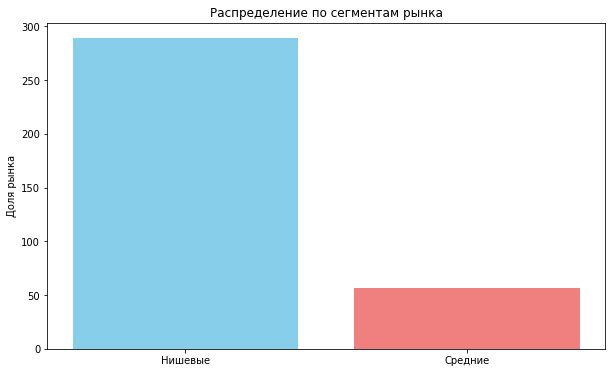

In [31]:
#строим график разделения на нишевые и средние сегменты.
categories = ['Нишевые', 'Средние']
ratios = [niche_count, medium_count]
colors = ['skyblue', 'lightcoral']
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, ratios, color=colors)  
plt.title('Распределение по сегментам рынка')
plt.ylabel('Доля рынка')
plt.show()

Вывод: больше всего нишевых категорий - 289.

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [32]:
#создаём копию датасета
df_modified = df_clean.copy()
# Получаем списки сегментов по категориям
massive_segments = grouped_data_market[grouped_data_market > 120].index.tolist()
medium_segments = grouped_data_market[(grouped_data_market >= 35) & (grouped_data_market <= 120)].index.tolist()
niche_segments = grouped_data_market[grouped_data_market < 35].index.tolist()
#заменяем значения в столбце market
df_modified.loc[df_modified['market'].isin(medium_segments), 'market'] = 'mid'
df_modified.loc[df_modified['market'].isin(niche_segments), 'market'] = 'niche'
df_modified['market'].unique()

array(['Education', 'Нет Данных', 'mid', 'Social Media',
       'Hardware + Software', 'Biotechnology', 'Hospitality',
       'Enterprise Software', 'Manufacturing', 'Finance', 'Design',
       'niche', 'Nonprofits', 'Software', 'Curated Web', 'Health Care',
       'Health And Wellness', 'Clean Technology', 'Web Hosting',
       'E-Commerce', 'Automotive', 'Medical', 'Fashion', 'Security',
       'Networking', 'Analytics', 'Semiconductors', 'Public Relations',
       'Travel', 'Consulting', 'Real Estate', 'Technology', 'Music',
       'Advertising', 'Games', 'Mobile', 'Internet', 'Sports',
       'Photography', 'News', 'Search', 'Messaging', 'Video',
       'Marketplaces', 'Entertainment', 'Saas', 'Cloud Computing',
       'Big Data', 'Apps', 'Social Network Media', 'Startups'],
      dtype=object)

In [33]:
#считаем долю сегментов относящих к массовым, средним, нишевым
#данные берем из датасета df_clean
total_segments = df_clean['market'].nunique()
mass_ratio = round((massive_count / total_segments) * 100,2)
niche_ratio = round((niche_count / total_segments) * 100,2)
medium_ratio = round((medium_count / total_segments) * 100,2)

print(mass_ratio)
print(niche_ratio)
print(medium_ratio)

12.41
73.16
14.43


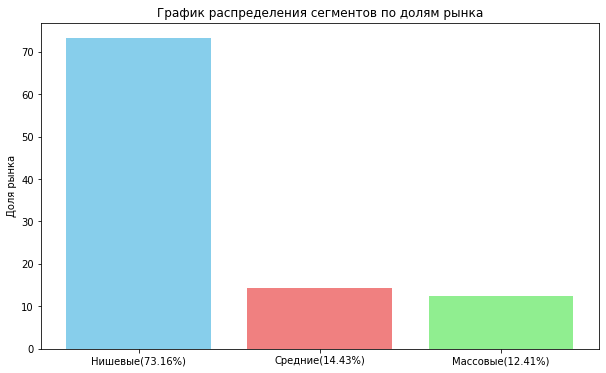

In [34]:
#строим график с долями сегментов
categories = ['Нишевые(73.16%)', 'Средние(14.43%)', 'Массовые(12.41%)']
ratios = [niche_ratio, medium_ratio, mass_ratio]
colors = ['skyblue', 'lightcoral', 'lightgreen']
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, ratios, color=colors)  
plt.title('График распределения сегментов по долям рынка')
plt.ylabel('Доля рынка')
plt.show()

Распределение сегментов по долям рынка:<br> 
Нишевые (73.16%), Средние (14.43%), Массовые (12.41%).

In [35]:
#считаем долю компаний занятых в массовом, среднем, нишевом сегментах
#данные берем из датасета df_modified (где поставили заглушки средним и нишевым категориям)
total_names = df_modified['name'].nunique()


massive_companies = df_modified[(df_modified['market'] != 'mid') & (df_modified['market'] != 'niche')]['name'].nunique()
medium_companies = df_modified[df_modified['market'] == 'mid']['name'].nunique()
niche_companies = df_modified[df_modified['market'] == 'niche']['name'].nunique()

mass_ratio_names = round((massive_companies / total_names) * 100 ,2)
niche_ratio_names = round((niche_count / total_names) * 100 ,2)
medium_ratio_names = round((medium_companies / total_names) * 100 ,2)

print(mass_ratio_names)
print(niche_ratio_names)
print(medium_ratio_names)

88.63
0.71
9.39


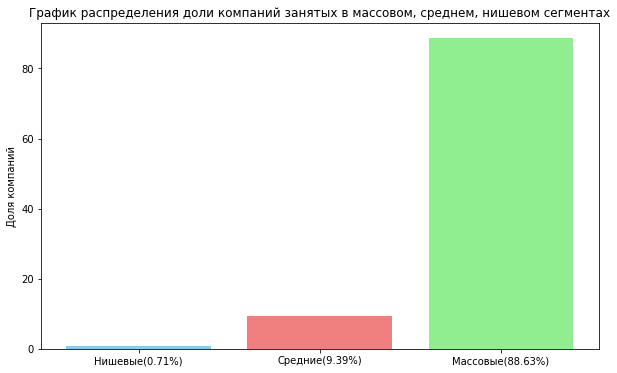

In [36]:
#строим график распределения с долями компаний
categories = ['Нишевые(0.71%)', 'Средние(9.39%)', 'Массовые(88.63%)']
ratios = [niche_ratio_names, medium_ratio_names, mass_ratio_names]
colors = ['skyblue', 'lightcoral', 'lightgreen']
plt.figure(figsize=(10, 6))
bars = plt.bar(categories, ratios, color=colors)  
plt.title('График распределения доли компаний занятых в массовом, среднем, нишевом сегментах')
plt.ylabel('Доля компаний')
plt.show()

Распределение компаний по сегментам рынка:<br> 
Нишевые (0.71%), Средние (9.39%), Массовые (88.63%).

Предположительный вывод по итогам анализа сегментов рынка:<br> 
Большинство стартапов (88.63 %) ориентируются на массовый рынок, но их общая доля всего 12.41 %, что отражает высокую конкуренцию и низкую маржинальность таких проектов. Нишевые стартапы, напротив, при мизерном числе компаний (0.71 %) занимают 73.16 % рынка за счёт высокой ценности своих решений. Средние стартапы (9.39 % компаний, 14.43 % доли) выполняют роль связующего звена. Такое распределение создаёт такую тенденцию: массовые проекты формируют конкуренцию, нишевые - драйверы роста, средние - масштабируют инновации.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

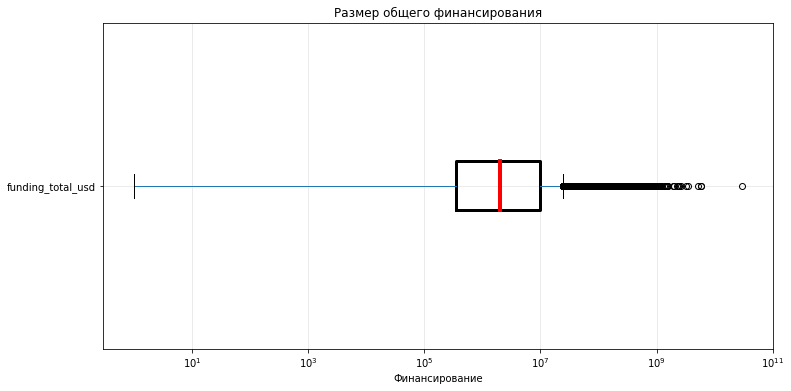

Статистика данных:
count    4.090100e+04
mean     1.591456e+07
std      1.686911e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64


In [37]:
#предварительно скорректируем тип данных у funding_total_usd
df_modified['funding_total_usd'] = df_modified['funding_total_usd'].astype(int)
#нарисуем ящик с усами
boxplot = df_modified.boxplot(
    column='funding_total_usd',
    vert=False,
    boxprops=dict(linewidth=3),
    medianprops=dict(linewidth=4, color='red'),
    figsize=(12, 6)
)
plt.xscale('log')  
boxplot.set_title('Размер общего финансирования')
boxplot.set_xlabel('Финансирование')
plt.grid(True, alpha=0.3)
plt.show()
#выведем статистики поля funding_total_usd
print("Статистика данных:")
print(df_modified['funding_total_usd'].describe())


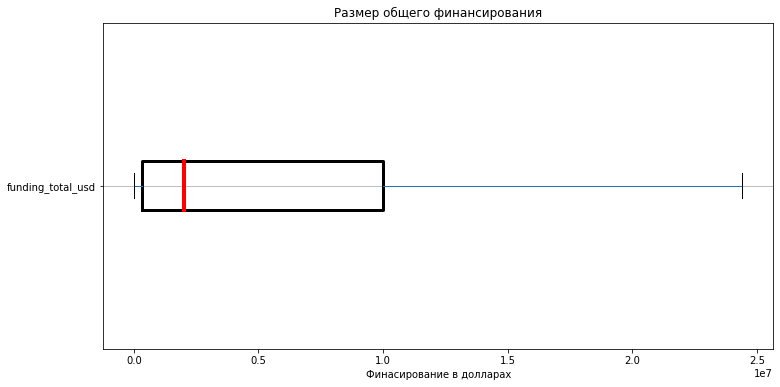

In [38]:
#ящик с усами без выбросов
boxplot = df_modified.boxplot(column='funding_total_usd',
                              vert=False,
                              boxprops=dict(linewidth=3),  
                              medianprops=dict(linewidth=4, color='red'),
                              figsize=(12, 6),
                              showfliers=False)


boxplot.set_title('Размер общего финансирования')
boxplot.set_xlabel('Финасирование в долларах')
plt.grid(axis='x', alpha=0.3)
plt.show() 

Вывод: типичное значение 25 млн долларов. Медиана около 2 млн долларов. 

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [39]:
#ищем компании с аномальным финансированием
#считаем IQR
Q1 = df_modified.groupby('market')['funding_total_usd'].quantile(0.25)
Q3 = df_modified.groupby('market')['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#добавляем границы
df_with_bounds = df_modified.copy()
df_with_bounds['lower'] = df_with_bounds['market'].map(lower_bound)
df_with_bounds['upper'] = df_with_bounds['market'].map(upper_bound)

#находим аномалии
anomalous_mask = (
    (df_with_bounds['funding_total_usd'] < df_with_bounds['lower']) |
    (df_with_bounds['funding_total_usd'] > df_with_bounds['upper'])
)
anomalous_companies = df_with_bounds[anomalous_mask].sort_values(by='funding_total_usd', ascending=False)
print("Компании с аномальным финансированием:")
print(anomalous_companies[['name', 'funding_total_usd']])

Компании с аномальным финансированием:
                         name  funding_total_usd
623    Verizon Communications        30079503000
48499                Sberbank         5800000000
7074                Clearwire         5700000000
1432   Charter Communications         5162513431
295    First Data Corporation         3500000000
...                       ...                ...
29251                  Yerdle            5500000
25957        Science Exchange            5500000
6915             Creo Medical            5490339
12908                   Zinch            5486842
47254                  smartB            5445337

[5243 rows x 2 columns]


Вывод: наибольшее финансирование у Verizon Communication.

In [40]:
#считаем долю аномальных компаний по сегментам
# общее количество компаний в каждом сегменте
total_per_market = df_modified.groupby('market')['name'].nunique()

#количество аномальных компаний в каждом сегменте
anomalous_per_market = anomalous_companies.groupby('market')['name'].nunique()

#доля аномальных компаний (в %)
anomalous_share = (anomalous_per_market / total_per_market * 100).round(2)
top_anomalous_markets = anomalous_share.sort_values(ascending=False)

print("Топ сегментов рынка по доле компаний с аномальным финансированием:")
print(top_anomalous_markets.head(10))

Топ сегментов рынка по доле компаний с аномальным финансированием:
market
Real Estate        17.20
Entertainment      16.67
Consulting         16.62
Search             16.49
Cloud Computing    16.45
Saas               16.24
Photography        16.18
Technology         15.97
Video              15.96
niche              15.90
Name: name, dtype: float64


Вывод: сегмент Real Estate имеет бОльшую долю по аномальному финансированию.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [41]:
#проверим полноту данных за 2014 г
round_columns = ['round_a', 'round_b', 'round_c', 'round_d',
               'round_e', 'round_f', 'round_g', 'round_h']

#компании с хотя бы одним раундом
companies_with_rounds = df_modified[
    df_modified[round_columns].sum(axis=1) > 0
]

#среди них  те, у кого есть даты финансирования в 2014
companies_rounds_2014 = companies_with_rounds[
    (companies_with_rounds['first_funding_at'].dt.year == 2014) |
    (companies_with_rounds['last_funding_at'].dt.year == 2014)
]

print(f"Компаний с раундами A–H и датами в 2014: {len(companies_rounds_2014)}")


Компаний с раундами A–H и датами в 2014: 3562


In [42]:
#проверим полноту данных за 2014 другим способом
#фильтруем компании с финансированием в последний день 2014 года (31.12.2014)
last_day_2014 = pd.Timestamp('2014-12-31')
companies_funded_last_day = df_modified[
    (df_modified['first_funding_at'] == last_day_2014) |
    (df_modified['mid_funding_at'] == last_day_2014) |
    (df_modified['last_funding_at'] == last_day_2014)
]
print(f"Компаний с финансированием 31.12.2014: {len(companies_funded_last_day)}")

Компаний с финансированием 31.12.2014: 1


Вывод: данные за 2014 полные

In [43]:
#удаляем аномальные компании из исходного датасета
df_cleaned_ano = df_modified.drop(anomalous_companies.index)

print(f"\nУдалено аномальных записей: {len(anomalous_companies)}")
print(f"Осталось записей в очищенном датасете: {len(df_cleaned_ano)}")



Удалено аномальных записей: 5243
Осталось записей в очищенном датасете: 35658


In [44]:
#оставляем компании, которые
#получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.
#результат сохраняем в датасет df_finally_clean

#создаём копию исходного датасета
df_finally_clean = df_cleaned_ano.copy()

#приводим дату среднего раунда к типу datetime
df_finally_clean['mid_funding_at'] = pd.to_datetime(df_finally_clean['mid_funding_at'])

#извлекаем год из даты среднего раунда
df_finally_clean['mid_funding_year'] = df_finally_clean['mid_funding_at'].dt.year

#считаем суммарное количество раундов по годам
rounds_per_year = df_finally_clean.groupby('mid_funding_year')['funding_rounds'].sum()

#отбираем годы с 50+ суммарными раундами финансирования
high_activity_years = rounds_per_year[rounds_per_year >= 50].index.astype(int)

#выводим подробную статистику по годам с высокой активностью
print("Подробная статистика по годам с 50+ раундами:")
for year in sorted(high_activity_years):
    print(f"  {year}: {rounds_per_year[year]} раундов")

print(f"\nГоды с 50+ раундами финансирования: {sorted(high_activity_years.tolist())}")
print(f"Количество таких лет: {len(high_activity_years)}")

#оставляем только компании, которые получали финансирование
#в годы с 50+ суммарными раундами
df_finally_clean = df_finally_clean[df_finally_clean['mid_funding_year'].isin(high_activity_years)]

#статистика
print(f"\nИсходный размер датасета: {len(df_modified)}")
print(f"После фильтрации по годам с 50+ раундами: {len(df_finally_clean)}")
print(f"Удалено записей: {len(df_modified) - len(df_finally_clean)}")


Подробная статистика по годам с 50+ раундами:
  2000: 113 раундов
  2001: 66 раундов
  2002: 98 раундов
  2003: 125 раундов
  2004: 181 раундов
  2005: 948 раундов
  2006: 1849 раундов
  2007: 2842 раундов
  2008: 3663 раундов
  2009: 4617 раундов
  2010: 6134 раундов
  2011: 7576 раундов
  2012: 9707 раундов
  2013: 12880 раундов
  2014: 7119 раундов

Годы с 50+ раундами финансирования: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Количество таких лет: 15

Исходный размер датасета: 40901
После фильтрации по годам с 50+ раундами: 35583
Удалено записей: 5318


### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [45]:
#считаем какие типы финансирования сколько привлекли денег, 
#берем данные из датасета df_finally_clean, откуда удалили компании с аномальным финансированием
fin_types_sum = df_finally_clean[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                              'debt_financing', 'angel',
'grant', 'private_equity', 'post_ipo_equity',
'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().sort_values(ascending=False)
print(fin_types_sum)

venture                 1.290909e+11
seed                    9.430337e+09
debt_financing          8.178153e+09
private_equity          4.843109e+09
angel                   2.478924e+09
undisclosed             2.100352e+09
grant                   1.978799e+09
post_ipo_equity         1.946452e+09
convertible_note        5.660394e+08
post_ipo_debt           2.867183e+08
equity_crowdfunding     2.379606e+08
product_crowdfunding    1.860939e+08
secondary_market        4.528580e+07
dtype: float64


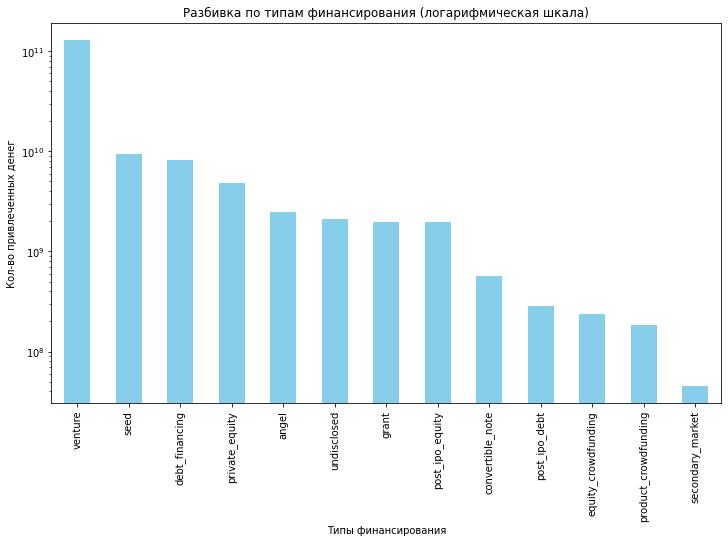

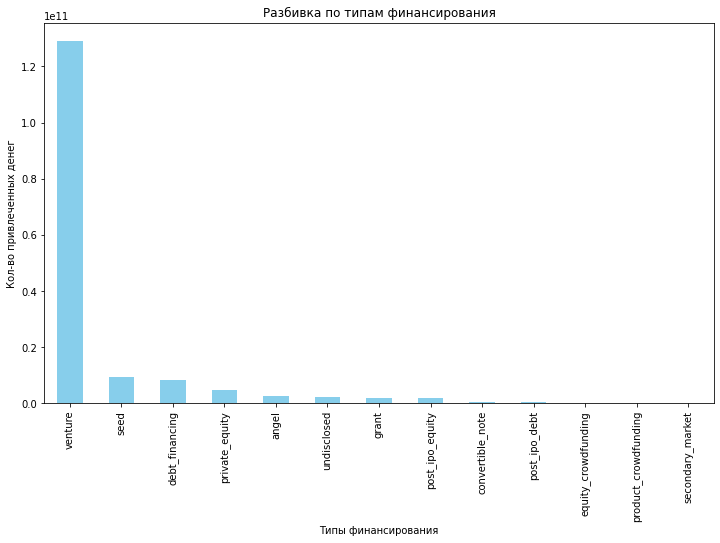

In [46]:
#строим график с лог шкалой
fin_types_sum.plot(
    kind='bar',
    title='Разбивка по типам финансирования (логарифмическая шкала)',
    legend=False,
    ylabel='Кол-во привлеченных денег',
    xlabel='Типы финансирования',
    rot=90,
    color='skyblue',
    figsize=(12, 7))
plt.yscale('log')  #добавляем логарифмический масштаб, в противном случае некоторые столбцы без него не видно

plt.show()

#строим график без лог шкалы
fin_types_sum.plot(
    kind='bar',
    title='Разбивка по типам финансирования',
    legend=False,
    ylabel='Кол-во привлеченных денег',
    xlabel='Типы финансирования',
    rot=90,
    color='skyblue',
    figsize=(12, 7))


plt.show()

Вывод: больше всего денег привлечено через тип venture, меньше всего - через тип secondary_market.                 

In [47]:
#популярность разных типов финансирования
#считаем кол-во ненулевых значений
fin_types_count = {}
columns_list = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
               'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
               'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

for col in columns_list:
    fin_types_count[col] = (df_finally_clean[col] > 0).sum()

fin_types_count = pd.Series(fin_types_count).sort_values(ascending=False)
print(fin_types_count)

venture                 18818
seed                    13372
debt_financing           3265
angel                    2935
grant                    1002
undisclosed               813
private_equity            634
convertible_note          521
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
dtype: int64


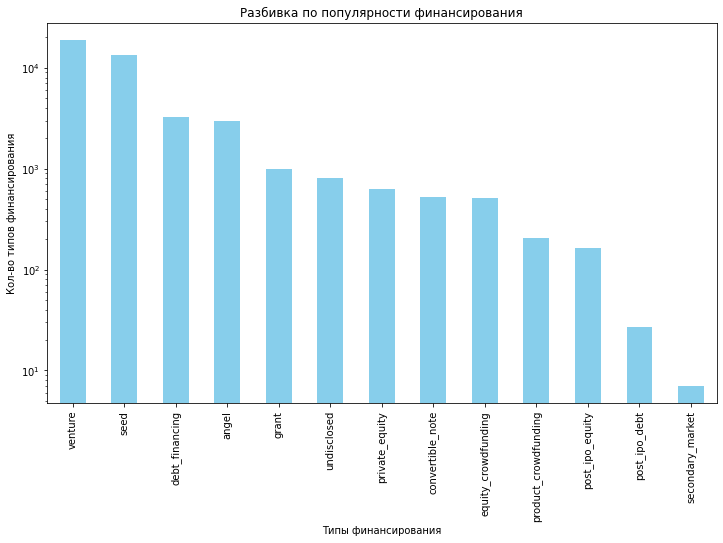

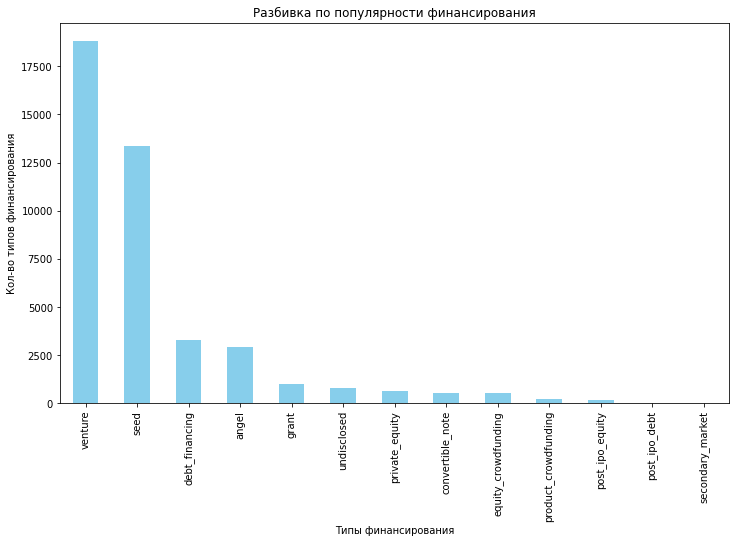

In [48]:
#строим график с лог шкалой
fin_types_count.plot(
    kind='bar',
    title='Разбивка по популярности финансирования',
    legend=False,
    ylabel='Кол-во типов финансирования',
    xlabel='Типы финансирования',
    rot=90,
    color='skyblue',
    figsize=(12, 7))
plt.yscale('log')  #добавляем логарифмический масштаб, в противном случае некоторые столбцы без него не видно

plt.show()

#строим график без лог шкалы
fin_types_count.plot(
    kind='bar',
    title='Разбивка по популярности финансирования',
    legend=False,
    ylabel='Кол-во типов финансирования',
    xlabel='Типы финансирования',
    rot=90,
    color='skyblue',
    figsize=(12, 7))


plt.show()

Вывод: в датасете больше всего типов venture,  меньше всего типов secondary_market. Результаты двух графиков совпадают.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [49]:
#считаем объем возвратов инвестиций
fin_return_sum = df_cb_returns[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                              'debt_financing', 'angel',
'grant', 'private_equity', 'post_ipo_equity',
'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum().sort_values(ascending=False)
print(fin_return_sum)

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64


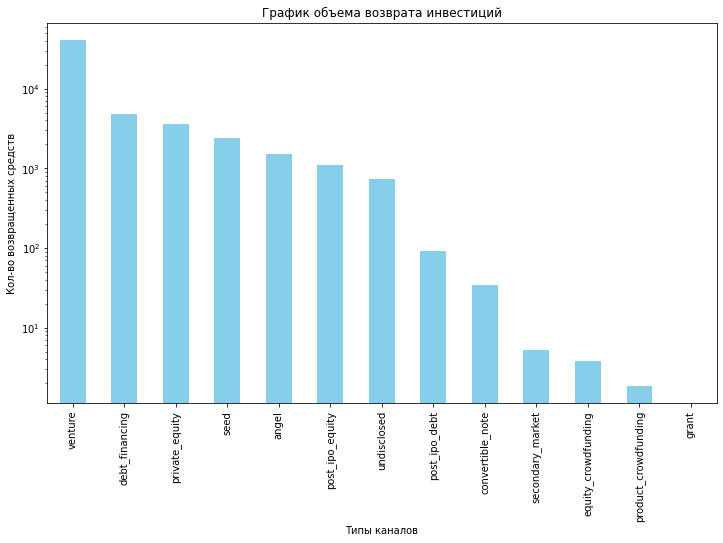

In [50]:
#строим график
fin_return_sum.plot(
    kind='bar',
    title='График объема возврата инвестиций',
    legend=False,
    ylabel='Кол-во возвращенных средств',
    xlabel='Типы каналов',
    rot=90,
    color='skyblue',
    figsize=(12, 7))
plt.yscale('log')  #добавляем логарифмический масштаб, в противном случае некоторые столбцы без него не видно

plt.show()

Вывод: и здесь лидирует тип venture. По типу grant возвратов не было.                      

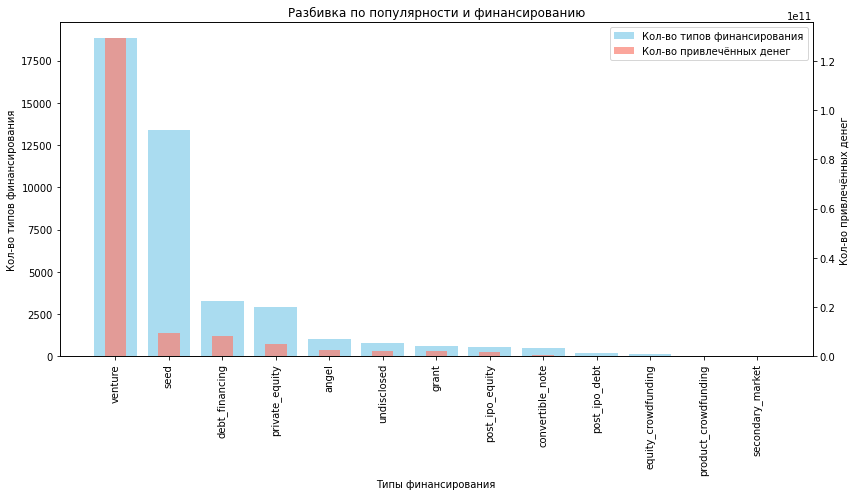

In [51]:
#строим два графика помощью twinx по популярности и финансированию

fig, ax1 = plt.subplots(figsize=(12, 7))

#основная ось (левая) — количество типов финансирования
ax1.bar(fin_types_count.index, fin_types_count.values,
         color='skyblue', alpha=0.7, label='Кол-во типов финансирования')
ax1.set_ylabel('Кол-во типов финансирования', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlabel('Типы финансирования')
ax1.tick_params(axis='x', rotation=90)

#доп. ось (правая) — сумма привлечённых денег
ax2 = ax1.twinx()
ax2.bar(fin_types_sum.index, fin_types_sum.values,
         color='salmon', alpha=0.7, width=0.4, label='Кол-во привлечённых денег')
ax2.set_ylabel('Кол-во привлечённых денег', color='black')
ax2.tick_params(axis='y', labelcolor='black')

plt.title('Разбивка по популярности и финансированию')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


Итоговый вывод по анализу всех графиков раздела:<br> 
Тип venture лидирует по популярности, по кол-ву превлеченных денег и по кол-ву вовзращенных средств.<br> 
Тип seed - на втором месте по популярности, но денег привлек не так много, особенно по сравнению с venture, находится на 4м месте по возврату инвестиций.  

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [52]:
#считаем для каждой компании средний объем средств одного раунда финансирования
mean_usd = round((df_finally_clean['funding_total_usd'] / df_finally_clean['funding_rounds']),2).sort_values(ascending=False)
mean_usd.index = df_finally_clean['name']
print(mean_usd)

name
University of New Brunswick        70000000.0
DuPont                             67700000.0
University of Michigan             65000000.0
Case Western Reserve University    65000000.0
Duke University                    65000000.0
                                      ...    
Grid4C                                   50.0
RiverSilica                              30.0
SouthGobi Resources                      22.0
DigiByte                                 14.0
Logovers                                  1.0
Length: 35583, dtype: float64


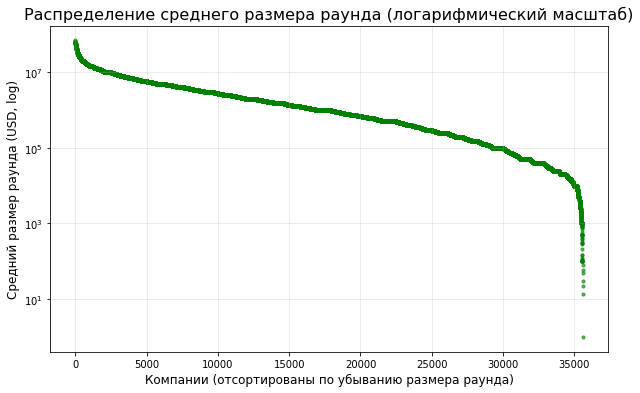

In [53]:
#построим точечную диаграмму, поскольку данных очень много
plt.figure(figsize=(10, 6))
plt.scatter(range(len(mean_usd)), mean_usd.values, alpha=0.6, color='green', s=10)
plt.yscale('log')  # Логарифмическая шкала по оси Y
plt.title('Распределение среднего размера раунда (логарифмический масштаб)', fontsize=16)
plt.xlabel('Компании (отсортированы по убыванию размера раунда)', fontsize=12)
plt.ylabel('Средний размер раунда (USD, log)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Вывод: кривая демонстрирует плавное снижение среднего размера раунда по мере удаления от лидеров (слева направо).


In [54]:
#готовим данные к построению графика
#динамика кол-ва финансирования за каждый год
#проверяем и сбрасываем индекс - чтобы избежать ошибки duplicate axis
if not df_finally_clean.index.is_unique:
    df_finally_clean = df_finally_clean.reset_index(drop=True)
    
#рассчитываем mean_usd с защитой от деления на ноль
#используем np.where: если funding_rounds == 0, ставим NaN
mean_usd = np.where(
    df_finally_clean['funding_rounds'] != 0,
    round(df_finally_clean['funding_total_usd'] / df_finally_clean['funding_rounds'], 2),
    np.nan
)
    

#добавляем столбец в датафрейм
df_finally_clean['mean_usd'] = mean_usd

#сортируем по убыванию значений mean_usd 
df_finally_clean = df_finally_clean.sort_values('mean_usd', ascending=False)
#сбрасываем индекс после сортировки - чтобы он был последовательным
df_finally_clean = df_finally_clean.reset_index(drop=True)
#преобразуем дату в год
date_column = 'mid_funding_at'
df_finally_clean['mid_funding_at'] = pd.to_datetime(df_finally_clean[date_column]).dt.year
#считаем медиану
groupped_data_usd_median = df_finally_clean.groupby('mid_funding_at')['mean_usd'].median()

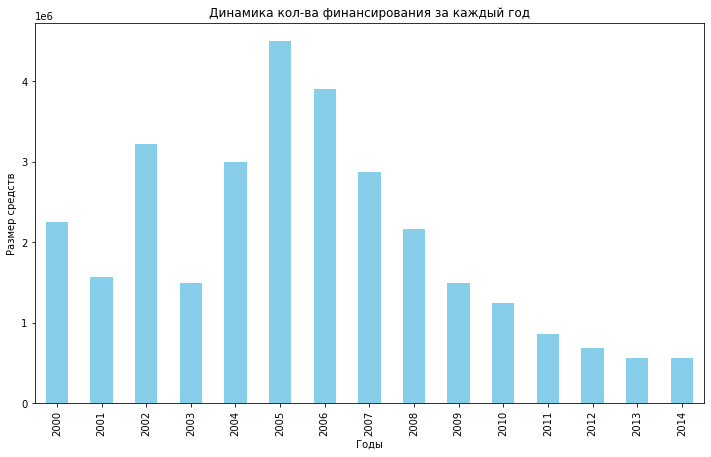

In [55]:
#строим график
groupped_data_usd_median.plot(
    kind='bar',
    title='Динамика кол-ва финансирования за каждый год',
    legend=False,
    ylabel='Размер средств',
    xlabel='Годы',
    rot=90,
    color='skyblue',
    figsize=(12, 7))


plt.show()

Вывод: в 2005 была самая большая медиана финансирования.

In [56]:
#считаем общее кол-во раундов финансирования за каждый год

total_rounds_by_year = df_finally_clean.groupby('mid_funding_at')['funding_rounds'].sum()
print(total_rounds_by_year)

mid_funding_at
2000      113
2001       66
2002       98
2003      125
2004      181
2005      948
2006     1849
2007     2842
2008     3663
2009     4617
2010     6134
2011     7576
2012     9707
2013    12880
2014     7119
Name: funding_rounds, dtype: int64


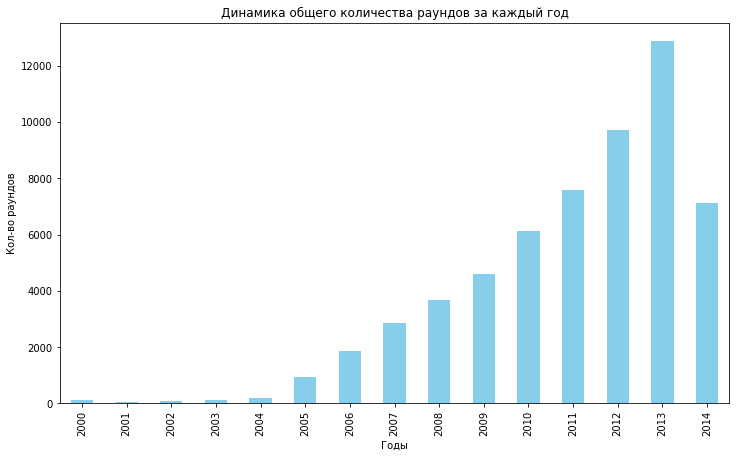

In [57]:
#строим график
total_rounds_by_year.plot(
    kind='bar',
    title='Динамика общего количества раундов за каждый год',
    legend=False,
    ylabel='Кол-во раундов',
    xlabel='Годы',
    rot=90,
    color='skyblue',
    figsize=(12, 7))


plt.show()


Вывод: в 2014 году было больше всего раундов финансирования - 18784.

In [58]:
#отвечаем на вопрос: 
#какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?
#а именно надо узнать в 2014 году сколько было раундов и сколько было средств в среднем на каждый раунд.
#фильтруем данные — оставляем только компании с последним финансированием в 2014 году
df_2014 = df_finally_clean[df_finally_clean['mid_funding_at'] == 2014]
#рассчитываем mean_usd именно для данных 2014 года
mean_usd_2014 = round((df_2014['funding_total_usd'] / df_2014['funding_rounds']), 2)
#считаем общее количество раундов финансирования в 2014 году
total_rounds_2014 = df_2014['funding_rounds'].sum()
mean_usd_2014.index = df_2014['name']

# Сортируем по убыванию
mean_usd_2014_sorted = mean_usd_2014.sort_values(ascending=False)


print(f"Общее количество раундов финансирования: {total_rounds_2014}")
print('Среднее количество средств на один раунд в 2014:')
print(mean_usd_2014_sorted)

Общее количество раундов финансирования: 7119
Среднее количество средств на один раунд в 2014:
name
Gear Energy                          63500000.0
CarePayment                          60000000.0
Geo Renewables                       55400000.0
Vanda Pharmaceuticals                54000000.0
Advanced Accelerator Applications    52750600.0
                                        ...    
Hair Scynce                               100.0
Shop 9 Seven                               80.0
The Manly Man Can                          30.0
MICEit.co                                  14.0
Deck Works.co                               1.0
Length: 6081, dtype: float64


In [59]:
#выведем статистики для поля с mean_usd
print(mean_usd_2014.describe())


count    6.081000e+03
mean     2.203720e+06
std      4.635398e+06
min      1.000000e+00
25%      1.098700e+05
50%      5.612380e+05
75%      2.000620e+06
max      6.350000e+07
dtype: float64


Вывод: в 2014 году общее количество раундов финансирования составило 7119.<br>
Максимальное среднее кол-во средств у компании Gear Energy.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [60]:
#преобразуем дату в год
date_column = 'last_funding_at'
df_finally_clean['last_funding_at'] = pd.to_datetime(df_finally_clean[date_column]).dt.year
#создаем сводную таблицу
pivot_table = pd.pivot_table(
    df_finally_clean,
    values='funding_total_usd',
    index='market',
    columns='last_funding_at',
    aggfunc='sum',
    fill_value=0
)
print(pivot_table)


 

last_funding_at           2000      2001      2002      2003      2004  \
market                                                                   
Advertising            8250000   8778321   6220000         0  16500000   
Analytics              1200000         0         0         0  10500000   
Apps                         0         0         0         0         0   
Automotive                   0         0         0   4530000         0   
Big Data                     0         0         0         0         0   
Biotechnology                0         0         0         0  68273683   
Clean Technology             0         0         0         0         0   
Cloud Computing       11500000         0         0         0         0   
Consulting                   0         0   4500000         0         0   
Curated Web            1000000         0   4650000    250000  13500000   
Design                       0         0         0         0         0   
E-Commerce            15700000   88000

In [61]:
#берем из сводной таблицы только те сегменты,
#которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013
years_needed = [2013, 2014]
pivot_filtered_years = pivot_table[years_needed]

#удаляем сегменты mid, niche, нет данных
segments_to_remove = ['mid', 'niche', 'Нет Данных']
pivot_cleaned = pivot_filtered_years.drop(index=segments_to_remove, errors='ignore')

#оставляем только сегменты, где есть данные за оба года 
pivot_with_both_years = pivot_cleaned[
    (pivot_cleaned[2013] > 0) & (pivot_cleaned[2014] > 0)
]

#тбираем сегменты с ростом в 2014 году относительно 2013
growth_segments = pivot_with_both_years[
    pivot_with_both_years[2014] > pivot_with_both_years[2013]
]

#сохраняем названия сегментов в отдельную переменную для дальнейшего построения графика
segments_for_plot = growth_segments.index.tolist()

print("Сегменты с ростом финансирования в 2014 году:")
print(segments_for_plot)

Сегменты с ростом финансирования в 2014 году:
['Advertising', 'Analytics', 'Apps', 'Big Data', 'Biotechnology', 'Clean Technology', 'Cloud Computing', 'Curated Web', 'Design', 'E-Commerce', 'Education', 'Entertainment', 'Fashion', 'Finance', 'Hardware + Software', 'Health And Wellness', 'Health Care', 'Hospitality', 'Internet', 'Manufacturing', 'Marketplaces', 'Medical', 'Messaging', 'Mobile', 'Music', 'Networking', 'News', 'Photography', 'Public Relations', 'Real Estate', 'Saas', 'Search', 'Security', 'Semiconductors', 'Social Media', 'Social Network Media', 'Software', 'Sports', 'Startups', 'Technology', 'Travel', 'Video', 'Web Hosting']


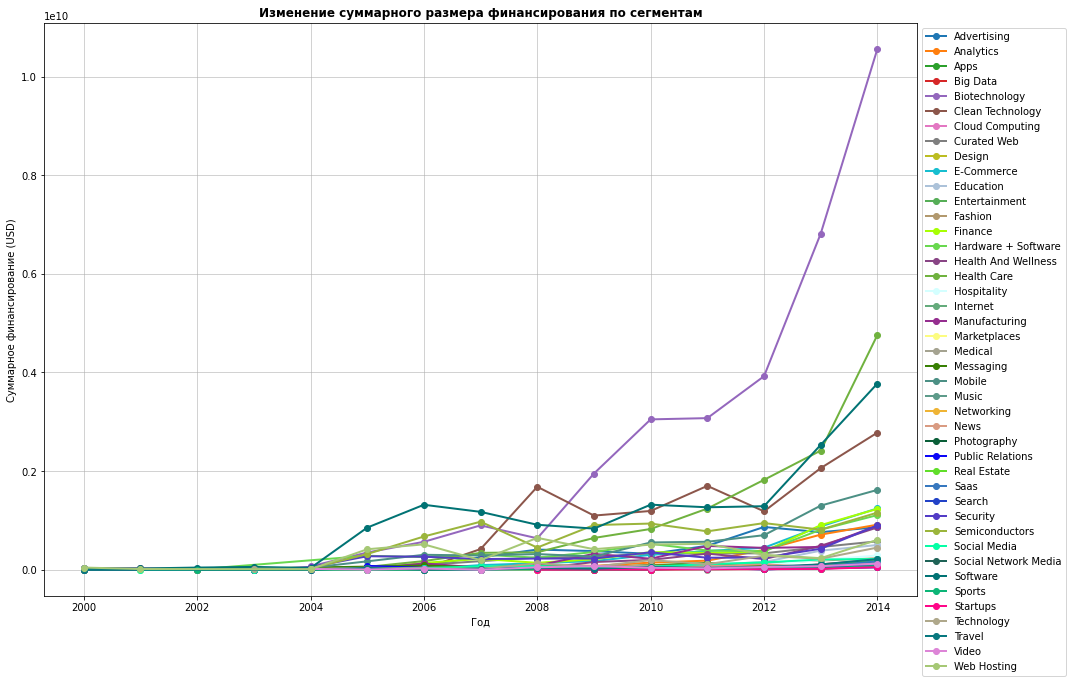

In [62]:
#строим график 
#как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам

#берем разные цвета для разных сегментов
colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.XKCD_COLORS.values())
colors = colors[:len(segments_for_plot)]  # обрезаем до числа сегментов

plt.figure(figsize=(15, 10))

for i, segment in enumerate(segments_for_plot):  # ИЗМЕНЕНО: добавили enumerate и индекс i
    segment_data = df_finally_clean[df_finally_clean['market'] == segment]
    yearly_sum = segment_data.groupby('last_funding_at')['funding_total_usd'].sum()
    
    plt.plot(
        yearly_sum.index,     
        yearly_sum.values,    
        marker='o',
        linewidth=2,
        label=segment,
        color=colors[i]        # задаём цвет по индексу из подготовленной палитры
    )

plt.title('Изменение суммарного размера финансирования по сегментам', fontsize=12, fontweight='bold')
plt.xlabel('Год', fontsize=10)
plt.ylabel('Суммарное финансирование (USD)', fontsize=10)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.7)
plt.tight_layout()
plt.show()

Самый большой рост у сегмента Biotechnology.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [63]:
#какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам
#считаем объем возвратов инвестиций по годам
grouped_data_return = df_cb_returns.groupby('year')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                              'debt_financing', 'angel',
'grant', 'private_equity', 'post_ipo_equity',
'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

#считаем объем вложенных инвестиций по годам
grouped_data_invested = df_finally_clean.groupby('last_funding_at')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
                              'debt_financing', 'angel',
'grant', 'private_equity', 'post_ipo_equity',
'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()
normalized_value = ((grouped_data_return / (grouped_data_invested + 1e-60)) * 100) * 1000000


#фильтруем данные — убираем проценты возвратов > 150% (вместо метода IQR)
normalized_value_cleaned = normalized_value.copy()

#проходим по всем столбцам и строкам, заменяем значения > 150% на NaN
for column in normalized_value_cleaned.columns:
    normalized_value_cleaned.loc[normalized_value_cleaned[column] > 150, column] = np.nan

print("Нормализованные значения (с заменой выбросов на NaN ):")
print(normalized_value_cleaned)

Нормализованные значения (с заменой выбросов на NaN ):
            seed     venture  equity_crowdfunding  undisclosed  \
year                                                             
2000         NaN   39.039608             0.000000   104.095903   
2001  108.161905   19.923181             0.000000    57.622724   
2002   94.954145  133.502407             0.000000   129.589965   
2003         NaN         NaN             0.000000    18.656304   
2004   85.605456         NaN             0.000000    48.617535   
2005  110.284580   70.272020             0.000000   129.196562   
2006         NaN   51.894844                  NaN          NaN   
2007   66.447187   52.568850                  NaN    71.682606   
2008   42.556814   33.827691                  NaN    71.326984   
2009   94.062711   26.267223            19.291426    75.154786   
2010   94.147694   26.433737            97.500000    36.337286   
2011   48.318205   29.955408            54.525627    22.895176   
2012   31.654663   33

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

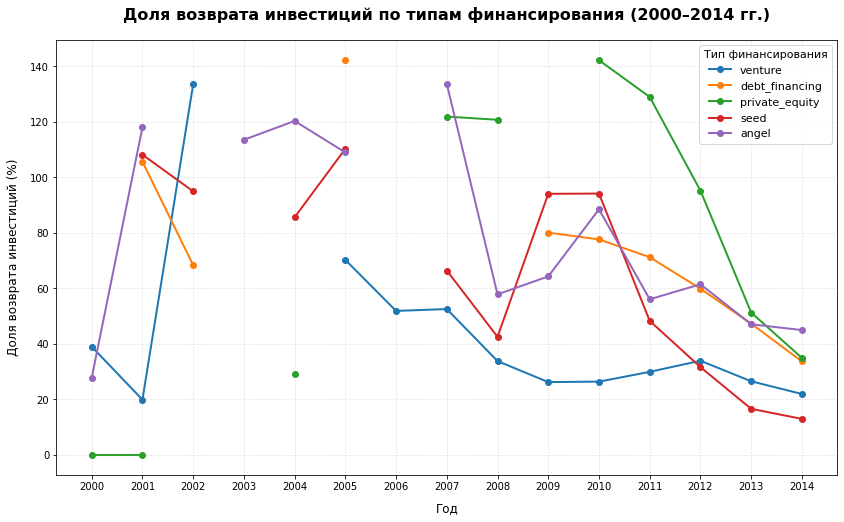

In [64]:
#строим график 
columns_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
data_to_plot = normalized_value_cleaned[columns_to_plot]

plt.figure(figsize=(14, 8))
for column in columns_to_plot:
    plt.plot(
        data_to_plot.index,
        data_to_plot[column],
        marker='o',
        linewidth=2,
        label=column
    )

plt.title('Доля возврата инвестиций по типам финансирования (2000–2014 гг.)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Год', fontsize=12, labelpad=10)
plt.ylabel('Доля возврата инвестиций (%)', fontsize=12, labelpad=10)
plt.xticks(data_to_plot.index)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Тип финансирования', fontsize=11, title_fontsize=11)
plt.show()


К 2014 году видна устройчивая тенденция спада возврата средств.<br>
В 2007 был самый высокие показатель возврата по private_equity, но судя по графику это самые не стабильный тип финансирования.<br>
Наиболее стабильный тип - angel.

Можно ли сказать что снижение/рост по категории говорит о том что этот тип финансирования становится все менее/более эффективным, или не все так однозначно?<br>
Не все так однозначно - лучше опираться на стабильность типа финансирования.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



Итоги проекта. 
1. Общий обзор проделанной работы:
* Было проанализировано два датасета: 
    * 1й с данными об инвестициях из 54294  строк и 40 столбцов.
    * 2й с данными о возврате инвестиций из 15 строк и 14 столбцов. 
* Была проведена предобработка данных, описаны промежуточные результаты, <span style="color: green">убраны неявные дубликаты из поля market.</span>
* Был проведен анализ данных по 8 задачам:
    * Рассчитаны требуемые показатели.
    * Построены соответствующие визуализации.
    * Под каждой визаулизацией указан краткий вывод.
    * Описаны обобщенные результаты проделанной работы. 

2. Ответы на вопросы по задачам.<br>

3  Шаг 2. Инжиниринг признаков.<br>
3.1  2.1. Группы по срокам финансирования.<br>
Компании разделены на три группы:<br>
Единичное финансирование — был всего один раунд финансирования.<br>
Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.<br>
Срок финансирования более года.<br>
Визуализировано соотношение этих групп:<br>
* По количеству компаний:
Итог: чаще всего встречается единчиное финансирование - 58.91%, финансирование со сроком до года и более года 30.09% и 11% соответственно.
* По объему инвестиций:
Итог: единичное финансирование (в долях) - 0.3054, финансирование со сроком до года 0.6195 и более года 0.0751.
Самая большая часть средств идет на финансирование более года - 61%.<br>

3.2  2.2 Выделение средних и нишевых сегментов рынка.<br>
Всего сегментов:<br>
Нишевые: 289<br>
Средние: 57<br>
Массовые: 49<br>
Посчитана и визуализирована доля сегментов относящих к массовым (12.41%), средним (73.16%), нишевым (14.43).<br>
Посчитана и визуализирована доля компаний занятых в массовом (88.63%), среднем (0.71%), нишевом (9.39%) сегментах.<br>
Сделан предположительный вывод по итогам анализа сегментов рынка:<br>
Большинство стартапов (88.63 %) ориентируются на массовый рынок, но их общая доля всего 12.41 %, что отражает высокую конкуренцию и низкую маржинальность таких проектов. Нишевые стартапы, напротив, при мизерном числе компаний (0.71 %) занимают 73.16 % рынка за счёт высокой ценности своих решений. Средние стартапы (9.39 % компаний, 14.43 % доли) выполняют роль связующего звена. Такое распределение создаёт такую тенденцию: массовые проекты формируют конкуренцию, нишевые - драйверы роста, средние - масштабируют инновации.<br>
Далее в столбце market остались только массовые сегменты. Для остальных сегментов заменены значения на заглушки — niche для нишевых и mid для средних. Дальнейшие исследования проводились с учетом этой замены.

4  Шаг 3. Работа с выбросами и анализ<br>
4.1  3.1. Анализируем и помечаем выбросы в каждом из сегментов.<br>
По столбцу funding_total_usd построен ящик с усами.<br>
Результат такой:<br>

всего - 4.090100e+04<br>
среднее - 1.591456e+07<br>
стандартное отклонение - 1.686911e+08<br>
мин значение - 1.000000e+00<br>
25 процентиль - 3.500000e+05<br>
медиана - 2.000000e+06<br>
75 процентиль - 1.000000e+07<br>
макс значение - 3.007950e+10<br>

Наибольшее финансирование у Verizon Communication.<br>
Топ сегментов рынка по доле компаний с аномальным финансированием:<br>

Real Estate        17.20<br>
Entertainment      16.67<br>
Consulting         16.62<br>
Search             16.49<br>
Cloud Computing    16.45<br>
Saas               16.24<br>
Photography        16.18<br>
Technology         15.97<br>
Technology         15.97<br>
Video              15.96<br>
niche              15.90<br>

4.2  3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии.<br>
* Проверено по датасету, что данные за 2014 год полные.
* Исключены из датасета компании, которые получили аномальное финансирование.
* Оставлены в датасете данные только о компаниях, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования. Новый датасет df_finally_clean.
* Удалено аномальных записей: 5243
* Осталось записей в очищенном датасете: 35658


4.3  3.3. Анализ типов финансирования по объёму и популярности.<br>
* Больше всего денег привлечено через тип venture, меньше всего - через тип secondary_market.
* В датасете больше всего типов venture,  меньше всего типов secondary_market. Результаты двух графиков совпадают.
* По возврату инвестиций также лидирует тип venture. По типу grant возвратов не было.<br>
Итоговый вывод по анализу всех графиков раздела:<br>
Тип venture лидирует по популярности, по кол-ву превлеченных денег и по кол-ву вовзращенных средств.
Тип seed - на втором месте по популярности, но денег привлек не так много, особенно по сравнению с venture, находится на 4м месте по возврату инвестиций.

5  Шаг 4. Анализ динамики<br>
5.1  4.1 Динамика предоставления финансирования по годам<br>
* Средний объем средств одного раунда финансирования для каждой компании, согласно точечной диаграмме, демонстрирует плавное снижение среднего размера раунда по мере удаления от лидеров (слева направо).
* В 2014 году было больше всего раундов финансирования - 18784.
* Максимальное среднее кол-во средств у компании Gear Energy.
* В 2005 была самая большая медиана финансирования. <span style="color: green">Комментарий студента V2: строка добавлена после ревью</span>

5.2  4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
* Построена сводная таблиц,а в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Выбраны только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.
* Построен график как менялось финансирование с 2000 по 2014 год, исключены сегменты 'mid' и 'niche' из результата, а также те, где нет данных.
* Самый большой рост у сегмента Biotechnology.

5.3  4.3 Годовая динамика доли возвращённых средств по типам финансирования.<br>
* Для каждого года и каждого вида финансирования рассчитаны нормированные значения возврата средств, исключены аномально высокие значения.
* Построен график, на котором отображены нормированные значения возврата средств для типов финансирования venture, debt_financing, private_equity, seed и angel.<br>
Итог: К 2014 году видна устройчивая тенденция спада возврата средств.
В 2007 был самый высокие показатель возврата по private_equity, но судя по графику это самые не стабильный тип финансирования.
Наиболее стабильный тип - angel.

Рекомендации заказчику: <br>
* в какую отрасль стоит инвестировать -  Biotechnology.<br>
* какой тип финансирования при этом будет наиболее уместным - angel - по нему самые стабильные показатели возвратов с 2000 по 2014 годы.